In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

In [2]:
df = pd.read_csv('..\\data\\segment2.csv')
df.head()

,lat,long,age,q_ihfc,q_ps,q_stein,ps_z,stein_z
0,48.7500,-127.75,2.906279,200.0,277.518538,299.158617,3096.673436,3222.245155
1,47.8983,-127.20,4.359262,161.0,226.597009,244.266377,3230.759601,3362.077870
2,47.8983,-127.65,3.190760,304.0,264.858297,285.511167,3125.194460,3251.988508
3,48.6833,-126.87,5.543758,60.8,200.936360,216.604786,3324.081515,3459.399294
4,48.6850,-126.87,5.543758,63.7,200.936360,216.604786,3324.081515,3459.399294


note that y = df[['ps_q']] will make the shape (#,#) but y = df['ps_q'] will make the shape (#,)

In [3]:
x = df.drop(columns=['q_ihfc','ps_z', 'stein_z', 'q_stein'])
y = df['ps_z']

In [4]:
x.head()

,lat,long,age,q_ps
0,48.7500,-127.75,2.906279,277.518538
1,47.8983,-127.20,4.359262,226.597009
2,47.8983,-127.65,3.190760,264.858297
3,48.6833,-126.87,5.543758,200.936360
4,48.6850,-126.87,5.543758,200.936360


In [5]:
x.shape

(3691, 4)

In [6]:
y.head()

0    3096.673436
1    3230.759601
2    3125.194460
3    3324.081515
4    3324.081515
Name: ps_z, dtype: float64

In [7]:
ts = 0.2

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=ts)

In [8]:
x_train.shape

(2952, 4)

this is the raw validation data

In [9]:
x_test.shape

(739, 4)

In [10]:
x_train.describe().round(3)

,lat,long,age,q_ps
count,2952.000,2952.000,2952.000,2952.000
mean,48.172,-128.310,1.781,570.469
std,0.322,0.664,1.654,622.744
min,47.686,-129.505,0.009,182.939
25%,47.885,-128.710,0.592,262.388
50%,48.294,-128.641,0.912,495.320
75%,48.455,-127.785,3.251,615.104
max,48.997,-126.223,6.688,5015.915


In [11]:
x_test.describe().round(3)

,lat,long,age,q_ps
count,739.000,739.000,739.000,739.000
mean,48.166,-128.337,1.721,602.147
std,0.323,0.634,1.588,699.169
min,47.686,-129.467,0.009,185.049
25%,47.878,-128.710,0.592,264.858
50%,48.252,-128.638,0.912,495.320
75%,48.455,-127.786,3.191,615.104
max,48.910,-126.291,6.537,5015.915


In [12]:
train_data = lgb.Dataset(x_train, label = y_train)
test_data = lgb.Dataset(x_test, label = y_test)

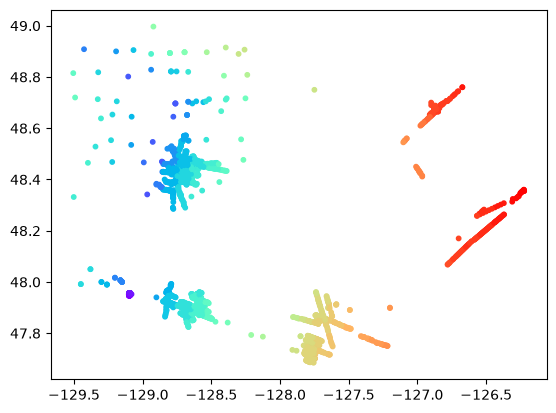

In [13]:
plt.scatter(x_train['long'], x_train['lat'], 
            c=y_train, cmap='rainbow', marker='o', s=10)

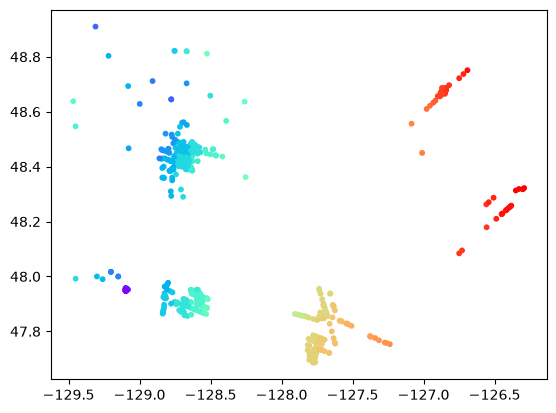

In [14]:
plt.scatter(x_test['long'], x_test['lat'], 
            c=y_test, cmap='rainbow', marker='o', s=10)

In [15]:
lr = 0.1

params = {
    'objective':'regression',
    'metric':'rmse',
    'boosting_type':'gbdt',
    'learning_rate':lr,
    'verbose':1
}

In [16]:
nbr = 100
model = lgb.train(params, train_data, valid_sets = [test_data], num_boost_round=nbr)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000686 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 662
[LightGBM] [Info] Number of data points in the train set: 2952, number of used features: 4
[LightGBM] [Info] Start training from score 2919.892052


In [17]:
y_pred = model.predict(x_test)

In [18]:
y_pred.shape

(739,)

In [19]:
y_pred, y_pred.shape

(array([3131.08234923, 2685.68942763, 2878.24062905, 2811.75784543,
        2878.21315088, 2878.23558059, 2916.44896967, 2878.23558059,
        2811.75784543, 3131.08234923, 3131.08234923, 3162.0311342 ,
        2769.20497598, 3131.08234923, 2705.05965241, 2769.20497598,
        2769.19421861, 2769.21050707, 3374.40246225, 2754.97307663,
        2811.75784543, 2769.21050707, 3336.83401729, 2704.81274081,
        3142.77046618, 2882.84314489, 2825.88383081, 2825.88383081,
        2834.35305525, 2878.24081527, 2560.4149052 , 2769.21050707,
        2855.85340583, 3339.38369543, 3131.08234923, 3289.31758786,
        2883.04327248, 3154.25363039, 2769.21050707, 2769.21050707,
        2878.24081527, 3131.08234923, 3207.83932029, 2769.19985232,
        3339.29456388, 3150.34719226, 3131.08234923, 2811.75784543,
        2813.81355302, 3150.32646498, 2769.21050707, 2769.21050707,
        3142.6528728 , 2834.35305525, 3131.08234923, 2754.90111419,
        2769.21050707, 3131.08234923, 3125.22336

In [20]:
residuals = y_test - y_pred

negative mean: overpredicting

In [21]:
residuals.head(), residuals.describe()

(992    -0.001388
 2983   -0.050180
 1227    0.004583
 1823   -0.008682
 2378    0.032061
 Name: ps_z, dtype: float64,
 count    739.000000
 mean      -0.014019
 std        0.544120
 min       -7.063979
 25%       -0.025793
 50%       -0.007521
 75%        0.014299
 max        3.433630
 Name: ps_z, dtype: float64)

In [22]:
dfr = pd.DataFrame({
    'long': x_test['long'].values,
    'lat': x_test['lat'].values,
    'ps_q_test_data': y_test,
    'ps_q_predicted': y_pred,
    'residual': residuals
})

saving both the csv file and a text file of specified parameters

In [23]:
pd.DataFrame(dfr).to_csv('..\\created_data\\seg2_ps_z_residuals.csv', index=False)

with open('..\\created_data\\seg2_ps_z_params.txt', 'w') as f:
    f.write('saving parameters for this dataset...\n')
    f.write(f'learning rate: {lr}\nnum_boost_rate: {nbr}\ntest size: {ts}\n')
    f.write(f'gives mean of: {residuals.mean()}')

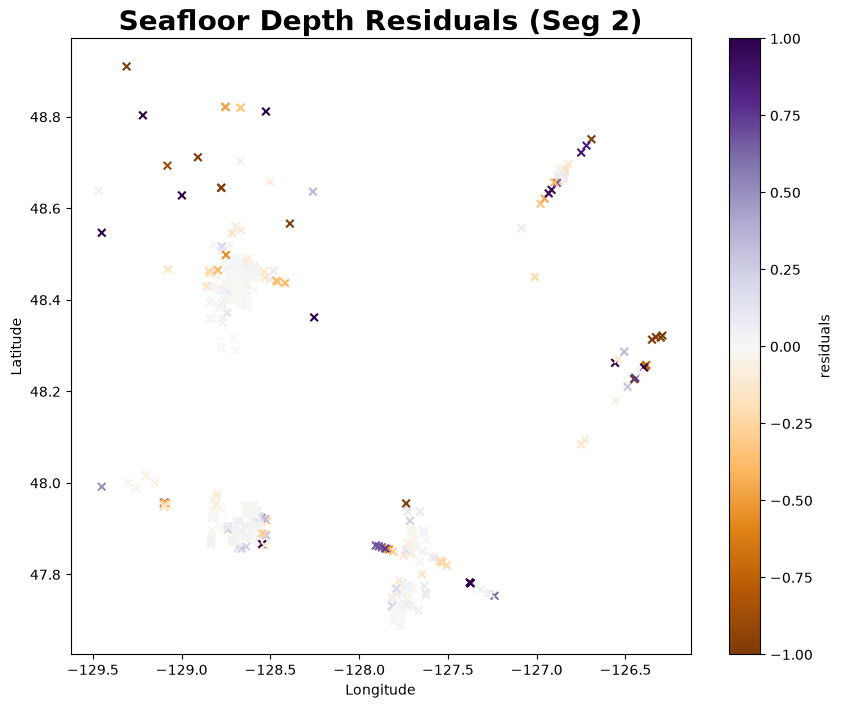

In [24]:
plt.figure(figsize=(10, 8))
plt.scatter(x_test['long'], x_test['lat'], c=residuals, cmap='PuOr',
            marker='x', s=30, vmin=-1, vmax=1)
plt.colorbar(label='residuals')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seafloor Depth Residuals (Seg 2)', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig('..\\figs\\res_ps_z_seg2.png', dpi=400)
plt.show()

## now we ... predict!

In [25]:
de = pd.read_csv('..\\data\\segment3.csv')
de.head()

,lat,long,age,q_ihfc,q_ps,q_stein,ps_z,stein_z
0,45.0033,-125.303,9.088325,60.0,156.934615,169.171914,3555.139683,3700.359955
1,45.0050,-125.303,9.088325,60.0,156.934615,169.171914,3555.139683,3700.359955
2,45.0033,-125.305,9.088325,102.0,156.934615,169.171914,3555.139683,3700.359955
3,45.0000,-125.321,9.088325,84.0,156.934615,169.171914,3555.139683,3700.359955
4,47.0633,-125.890,7.629121,100.0,171.286610,184.643035,3466.730210,3608.161504


In [63]:
xe = de.drop(columns=['q_ihfc','ps_z', 'stein_z', 'q_stein'])
ye = de['ps_z']

In [64]:
xe.head()

,lat,long,age,q_ps
0,45.0033,-125.303,9.088325,156.934615
1,45.0050,-125.303,9.088325,156.934615
2,45.0033,-125.305,9.088325,156.934615
3,45.0000,-125.321,9.088325,156.934615
4,47.0633,-125.890,7.629121,171.286610


In [75]:
sp = 250
grid_long = np.linspace(de['long'].min(), de['long'].max(), sp)
grid_lat = np.linspace(de['lat'].min(), de['lat'].max(), sp)

In [76]:
long, lat = np.meshgrid(grid_long, grid_lat)

In [77]:
long.shape, lat.shape

((250, 250), (250, 250))

Nearest copies the value of the closest data point, keeping original values sharp but blocky. Linear blends adjacent points using a straight line or weighted average.

In [114]:
age_interp = griddata((de['long'], de['lat']), de['age'], (long, lat), method='linear')
hf_interp  = griddata((de['long'], de['lat']), de['q_ps'], (long, lat), method='linear')

In [120]:
age_interp.shape, hf_interp.shape

((250, 250), (250, 250))

In [121]:
np.where(~np.isnan(age_interp))

(array([  1,   1,   1, ..., 249, 249, 249], shape=(50911,)),
 array([191, 192, 193, ..., 168, 169, 170], shape=(50911,)))

In [122]:
age_interp[190:195, 190:195], hf_interp[190:195, 190:195]

(array([[8.02527633, 8.07767871, 8.22799973, 8.26877746, 8.30644495],
        [8.02551494, 8.05631521, 8.21913522, 8.2568027 , 8.29447019],
        [8.02575355, 8.16497963, 8.20716046, 8.24482795, 8.28249543],
        [8.0085928 , 8.15751822, 8.1951857 , 8.23285319, 8.27052067],
        [8.10195952, 8.14554346, 8.18321095, 8.22087843, 8.25854592]]),
 array([[167.08054615, 166.54462162, 165.07059304, 164.67497876,
         164.31783736],
        [167.08638039, 166.77046859, 165.17281606, 164.81567466,
         164.45853325],
        [167.09221462, 165.72470524, 165.31351196, 164.95637056,
         164.59922915],
        [167.27497224, 165.81134926, 165.45420786, 165.09706645,
         164.73992505],
        [166.37881743, 165.95204516, 165.59490375, 165.23776235,
         164.88062095]]))

np.vstack stacks arrays as new rows

In [123]:
lola = np.vstack([long.ravel(), lat.ravel(), age_interp.ravel(), hf_interp.ravel()]).T

In [124]:
lola.shape

(62500, 4)

In [125]:
np.where(~np.isnan(lola))

array([], shape=(5, 0), dtype=float64)

ensure nans are just around the edges

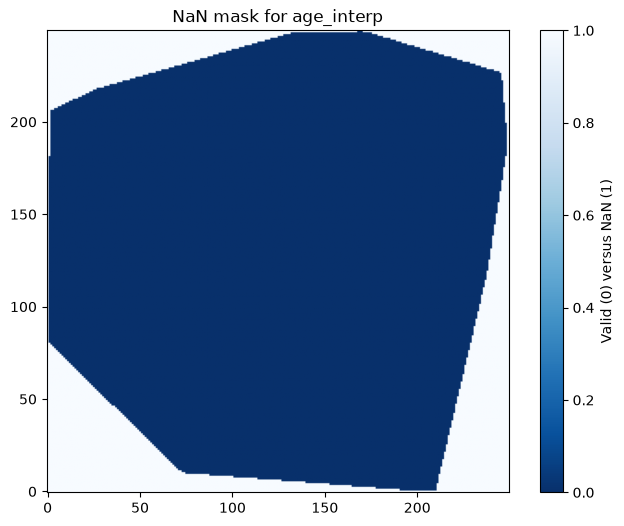

In [126]:
np.where(np.isnan(lola))

plt.figure(figsize=(8,6))
plt.imshow(np.isnan(age_interp), origin='lower', cmap='Blues_r')
plt.title('NaN mask for age_interp')
plt.colorbar(label='Valid (0) versus NaN (1)')
plt.show()

In [127]:
lola_pred = model.predict(lola)

In [128]:
lola_pred[0:5]

array([2743.31803047, 2743.31803047, 2743.31803047, 2743.31803047,
       2743.31803047])

In [129]:
lola_pred = lola_pred.reshape(long.shape)

In [130]:
lola_pred.shape

(250, 250)

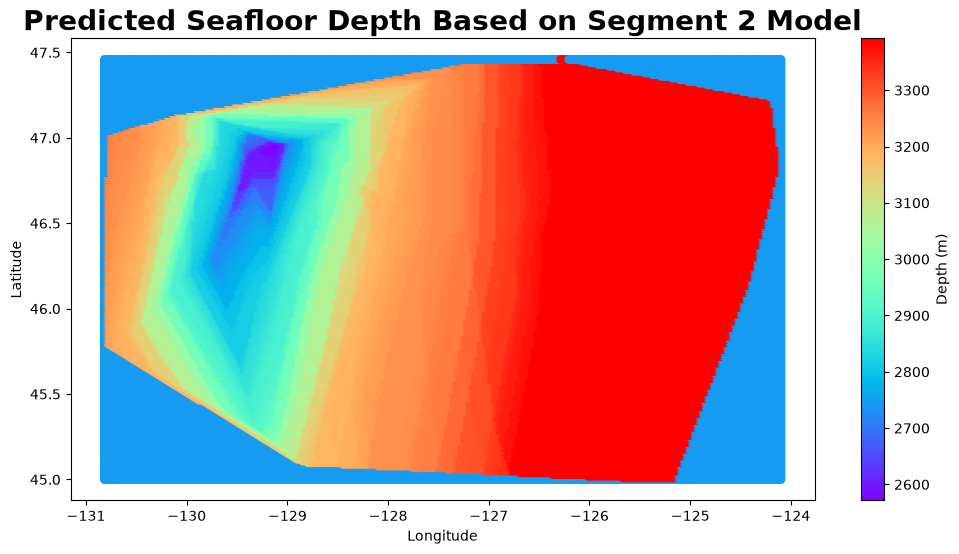

: 

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Depth (m)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Predicted Seafloor Depth Based on Segment 2 Model', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig(f'..\\figs\\xval_seg3_ps_z_pred_{sp}.png', dpi=400)
plt.show()